In [ ]:
# Logic Details :-
# Install all the Libraries and Dependencies
# Setting Random Seeds for Reproducibility
# Feature-Level Concatenation of MobileNetV2 and EfficientNet with CBAM Attention 
# Print the Accuracy and Loss curve
# Print the t-SNE scatter plot

# Install all the Libraries and Dependencies

In [4]:
import os, time
import numpy as np
import pandas as pd
from PIL import Image
!pip install torchinfo
import torch
from torchinfo import summary
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from tqdm.notebook import tqdm
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import matplotlib.pyplot as plt
import random
%matplotlib inline
plt.style.use('seaborn-v0_8')
#Resnet50, MobilenetV2, densenet121

# Setting Random Seeds for Reproducibility

In [5]:
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Feature-Level Concatenation of MobileNetV2 and EfficientNet with CBAM Attention

Device: cuda
Classes: ['Normal', 'OSCC']
Train: 4946 | Val: 120 | Test: 126


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 194MB/s]


Training:   0%|          | 0/619 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch [1/100]
 Train - Loss: 0.6112, Acc: 0.7905, Prec: 0.5278, Rec: 0.5271, F1: 0.5274
 Val   - Loss: 0.4802, Acc: 0.8417, Prec: 0.7915, Rec: 0.7352, F1: 0.7564
✅ Saved best ensemble checkpoint.


...

Training:   0%|          | 0/619 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch [100/100]
 Train - Loss: 0.2190, Acc: 0.9923, Prec: 0.9923, Rec: 0.9923, F1: 0.9923
 Val   - Loss: 0.4380, Acc: 0.9333, Prec: 0.9271, Rec: 0.8820, F1: 0.9018


Testing:   0%|          | 0/16 [00:00<?, ?it/s]


Test Results -> Loss: 0.4597, Acc: 0.9206, Prec: 0.9001, Rec: 0.8822, F1: 0.8906


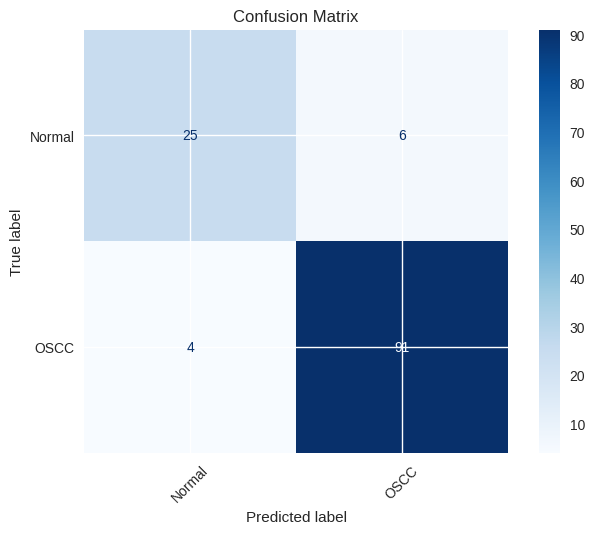

Raw fusion weights (models x classes):
[[-0.04801233 -0.04213284  0.02345889  0.02283651]
 [ 0.04801232  0.04213285 -0.02345889 -0.0228365 ]]
Normalized weights (softmax across models for each class):
[[0.4760123  0.47894603 0.5117273  0.51141626]
 [0.5239877  0.52105397 0.4882727  0.48858374]]


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# Dataset / transforms (same as yours)
# -------------------------
num_classes = 4  # user provided
data_dir = "/kaggle/input/oral-squamous-cell-carcinoma-classification/Oral Squamous Cell Carcinoma (OSCC)"
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")
batch_size = 8
num_workers = 4

train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=25, translate=(0.25,0.25), scale=(0.75,1.25)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
val_test_transform = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# -------------------------
# CBAM modules (exactly as you used)
# -------------------------
class SAM(nn.Module):
    def __init__(self, bias=False):
        super(SAM, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=bias)

    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        cat = torch.cat([max_pool, avg_pool], dim=1)
        out = self.conv(cat)
        out = torch.sigmoid(out) * x
        return out

class CAM(nn.Module):
    def __init__(self, channels, r=16):
        super(CAM, self).__init__()
        self.channels = channels
        self.r = r
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // r, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(channels // r, channels, bias=True)
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        max_pool = F.adaptive_max_pool2d(x, 1).view(b, c)
        avg_pool = F.adaptive_avg_pool2d(x, 1).view(b, c)
        out = self.fc(max_pool).view(b, c, 1, 1) + self.fc(avg_pool).view(b, c, 1, 1)
        out = torch.sigmoid(out) * x
        return out

class CBAM(nn.Module):
    def __init__(self, channels, r=16):
        super(CBAM, self).__init__()
        self.cam = CAM(channels, r=r)
        self.sam = SAM(bias=False)
    def forward(self, x):
        out = self.cam(x)
        out = self.sam(out)
        return out + x

# -------------------------
# MobileNetV2_CBAM (unchanged format)
# -------------------------
_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

class MobileNetV2_CBAM(nn.Module):
    def __init__(self, num_classes, pretrained_backbone=True):
        super(MobileNetV2_CBAM, self).__init__()
        self.features = _mobilenet.features
        self.cbam = CBAM(channels=1280, r=16)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        logits = self.classifier(x)
        return logits

# -------------------------
# ShuffleNetV2_CBAM (unchanged format)
# -------------------------
_efficientnet = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)

class EfficientNetB2_CBAM(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetB2_CBAM, self).__init__()
        self.backbone = _efficientnet.features  # feature extractor
        self.cbam = CBAM(channels=1408, r=16)   # EfficientNet-B2 output channels
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(1408, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

# -------------------------
# Ensemble Fusion Module (learnable per-class weights)
#  -> FIXED: returns (fused_logits, weights)
# -------------------------
class EnsembleFusion(nn.Module):
    def __init__(self, modelA: nn.Module, modelB: nn.Module, num_classes: int, freeze_backbones: bool = False, init_bias=None):
        super(EnsembleFusion, self).__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.num_models = 2
        self.num_classes = num_classes

        # initialize raw_weights (2 x C)
        if init_bias is not None:
            # user can pass an init tensor of shape (2, C)
            init = init_bias.clone().float()
        else:
            init = torch.zeros(2, num_classes)
        self.raw_weights = nn.Parameter(init)

        if freeze_backbones:
            for p in self.modelA.parameters(): p.requires_grad = False
            for p in self.modelB.parameters(): p.requires_grad = False

    def forward(self, x):
        logits_a = self.modelA(x)   # B x C
        logits_b = self.modelB(x)   # B x C
        stacked = torch.stack([logits_a, logits_b], dim=1)  # B x 2 x C

        # softmax across model dim (0) -> shape (2, C)
        weights = F.softmax(self.raw_weights, dim=0)  # (2, C)
        weights_exp = weights.unsqueeze(0).expand(stacked.size(0), -1, -1)  # B x 2 x C

        fused = (stacked * weights_exp).sum(dim=1)  # B x C

        return fused, weights

# -------------------------
# Instantiate models (exact user format)
# -------------------------
modelA = MobileNetV2_CBAM(num_classes=num_classes)
modelB = EfficientNetB2_CBAM(num_classes=num_classes)

# Optional: try to load your single-model checkpoints if they exist
ckptA = "/kaggle/working/MobileNetV2_lung-ct.pth"
ckptB = "/kaggle/working/EfficientNetB2_lung-ct.pth"
if os.path.exists(ckptA):
    try:
        modelA.load_state_dict(torch.load(ckptA, map_location=device))
        print("Loaded MobileNet weights from", ckptA)
    except Exception as e:
        print("Could not load MobileNet ckpt:", e)
if os.path.exists(ckptB):
    try:
        modelB.load_state_dict(torch.load(ckptB, map_location=device))
        print("Loaded ShuffleNet weights from", ckptB)
    except Exception as e:
        print("Could not load ShuffleNet ckpt:", e)

# Build ensemble (keep format)
freeze_backbones = False   # set True to only train fusion weights (safe), False to fine-tune whole net
# Optionally bias init so mobilenet has slightly larger initial weight:
init_bias = None
# init_bias = torch.tensor([[1.0]*num_classes, [0.0]*num_classes])  # uncomment to bias toward modelA initially

ensemble = EnsembleFusion(modelA, modelB, num_classes=num_classes, freeze_backbones=freeze_backbones, init_bias=init_bias).to(device)

# -------------------------
# Loss / Optimizer / Scheduler (fixed logic)
# -------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

if freeze_backbones:
    # optimize only fusion raw_weights
    optimizer = optim.AdamW([ensemble.raw_weights], lr=1e-2, weight_decay=1e-4)
else:
    # optimize full ensemble params (backbones + fusion)
    optimizer = optim.AdamW(ensemble.parameters(), lr=5e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# -------------------------
# Metrics helper (same as yours)
# -------------------------
def compute_metrics(y_true, y_pred, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return acc, prec, rec, f1

# -------------------------
# Train/validate/test loops (ADJUSTED to unpack (logits, weights))
# -------------------------
GRAD_CLIP = 1.0

def train_one_epoch_ensemble(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, weights = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, *compute_metrics(all_labels, all_preds)

def validate_one_epoch_ensemble(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Validation", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits, weights = model(imgs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, *compute_metrics(all_labels, all_preds)

def test_model_ensemble(model, loader, criterion, device, class_names):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Testing", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits, weights = model(imgs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(y_true, y_pred)
    print(f"\nTest Results -> Loss: {avg_loss:.4f}, Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()
    return avg_loss, acc, prec, rec, f1

# -------------------------
# Training runner (standard single-stage)
# -------------------------
def run_training_ensemble(model, train_loader, val_loader, test_loader, optimizer, criterion, device, num_epochs=100, early_stop_patience=10):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch_ensemble(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch_ensemble(model, val_loader, criterion, device)

        # step scheduler after val
        try:
            scheduler.step()
        except Exception:
            pass

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print(f" Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}, F1: {train_f1:.4f}")
        print(f" Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}, F1: {val_f1:.4f}")

        # save best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_ensemble.pth")
            print("✅ Saved best ensemble checkpoint.")
    

    # load best and test
    if os.path.exists("best_ensemble.pth"):
        model.load_state_dict(torch.load("best_ensemble.pth", map_location=device))
    test_model_ensemble(model, test_loader, criterion, device, class_names)
    # print fusion weights
    if hasattr(model, 'raw_weights'):
        print("Raw fusion weights (models x classes):")
        print(model.raw_weights.data.cpu().numpy())
        print("Normalized weights (softmax across models for each class):")
        print(F.softmax(model.raw_weights, dim=0).detach().cpu().numpy())
    return history

# -------------------------
# Run training
# -------------------------
ensemble = ensemble.to(device)
history = run_training_ensemble(ensemble, train_loader, val_loader, test_loader, optimizer, criterion, device, num_epochs=100, early_stop_patience=10)



In [7]:
# Save final ensemble weights
torch.save(ensemble.state_dict(), "/kaggle/working/best_ensemble.pth")
print("Saved ensemble to /kaggle/working/best_ensemble.pth")

Saved ensemble to /kaggle/working/best_ensemble.pth


# Print the Accuracy and Loss curve

📈 Plotting Ensemble Training Curves...


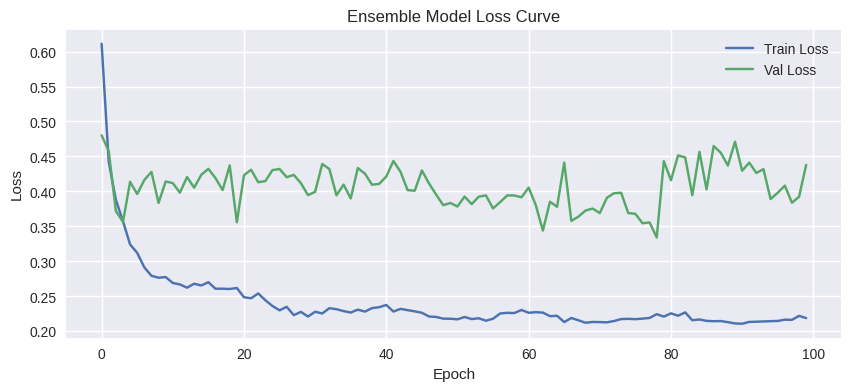

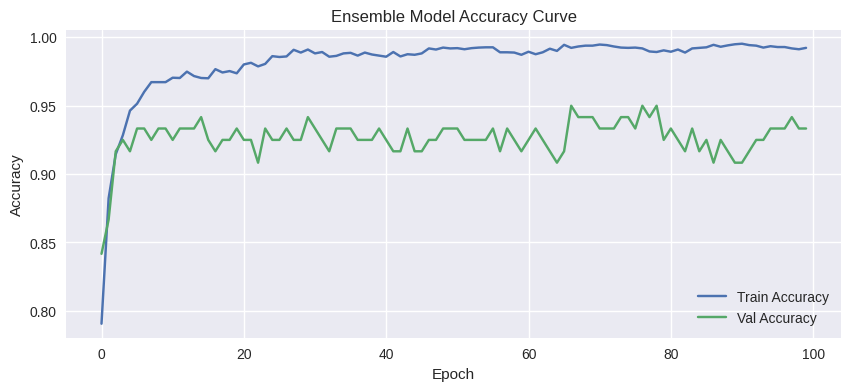

✅ Curves generated successfully.


In [ ]:
train_losses = history["train_loss"]
val_losses   = history["val_loss"]
train_accs   = history["train_acc"]
val_accs     = history["val_acc"]

print("📈 Plotting Ensemble Training Curves...")

# ---- LOSS CURVE ----
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ensemble Model Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---- ACCURACY CURVE ----
plt.figure(figsize=(10, 4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs,   label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Ensemble Model Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

print("✅ Curves generated successfully.")

# Print the t-SNE scatter plot


🔍 Generating t-SNE visualization for ENSEMBLE model...


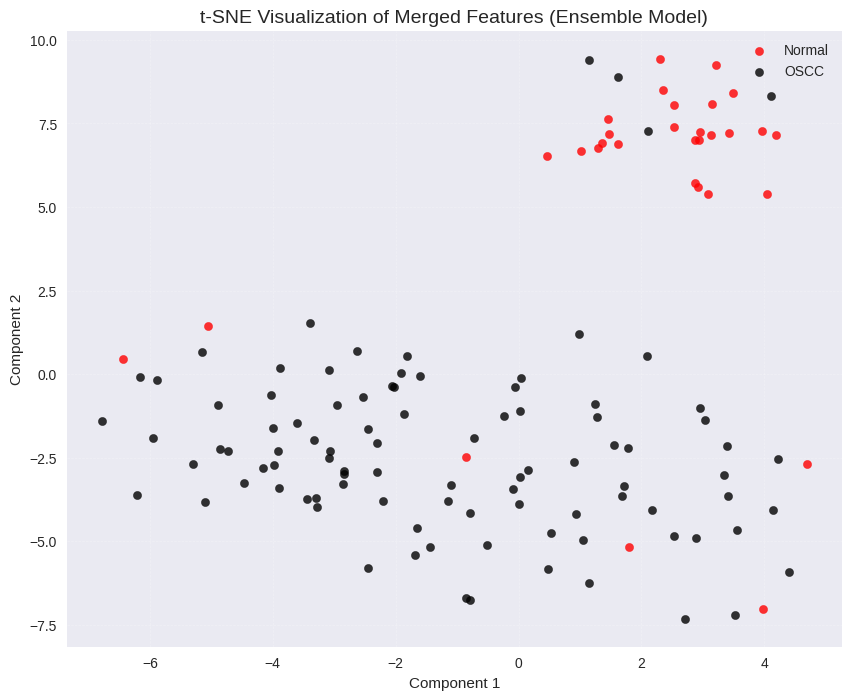

In [14]:
from sklearn.manifold import TSNE
# ---- Extract features from Ensemble Model ----
def extract_features_ensemble(ensemble_model, dataloader, device):
    ensemble_model.eval()
    features = []
    labels = []

    modelA = ensemble_model.modelA  # MobileNet
    modelB = ensemble_model.modelB  # EfficientNetB2_CBAM

    # Feature extractor for EfficientNet (remove classifier head)
    feature_extractor_B = torch.nn.Sequential(*list(modelB.children())[:-1]).to(device)

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)

            # ---- MobileNet Backbone ----
            featA = modelA.features(inputs)
            featA = F.adaptive_avg_pool2d(featA, (1, 1))
            featA = torch.flatten(featA, 1)

            # ---- EfficientNet Backbone ----
            featB = feature_extractor_B(inputs)
            featB = F.adaptive_avg_pool2d(featB, (1, 1))
            featB = torch.flatten(featB, 1)

            # ---- Merged Features ----
            merged = torch.cat([featA, featB], dim=1)

            features.append(merged.cpu().numpy())
            labels.append(targets.cpu().numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)
    return features, labels


# ---- t-SNE Visualization ----
def visualize_tsne_ensemble(ensemble_model, dataloader, device, class_names):
    print("\n🔍 Generating t-SNE visualization for ENSEMBLE model...")

    features, labels = extract_features_ensemble(ensemble_model, dataloader, device)

    # Run t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        learning_rate=200,
        init='pca'
    )
    tsne_results = tsne.fit_transform(features)

    # ---- Plot ----
    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        idx = labels == i

        # 🔴 Class 0 → Red | All other classes → Black ⚫
        color = 'red' if i == 0 else 'black'

        plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1],
                    label=class_name, s=35, alpha=0.8, c=color)

    plt.title("t-SNE Visualization of Merged Features (Ensemble Model)", fontsize=14)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.legend()
    plt.show()


# ---- Run ----
visualize_tsne_ensemble(ensemble, test_loader, device, class_names)
